In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import scipy

# Add the parent directory (which contains the fmcg package) to Python path
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

import fmcg
from fmcg.pipeline.preprocessing import load_and_preprocess
from fmcg.signal.filtering import filternk
from fmcg.utils.plotting.plot_utils import plot_sensor_signals
from fmcg.ica.ica_component_labeler import ICAComponentLabeler
from fmcg.spatial_filtering import SpatialFilter
from fmcg.analysis.hr import compute_hr
from fmcg.analysis.heartbeat_averaging import find_segments_and_average_heartbeats



logging.basicConfig(level=logging.ERROR, format="%(message)s", force=True)

SyntaxError: positional argument follows keyword argument (plot_utils.py, line 1663)

## Data Loading and Preprocessing

Preprocessed signal: 297.1s at 200 Hz, 24 valid channels


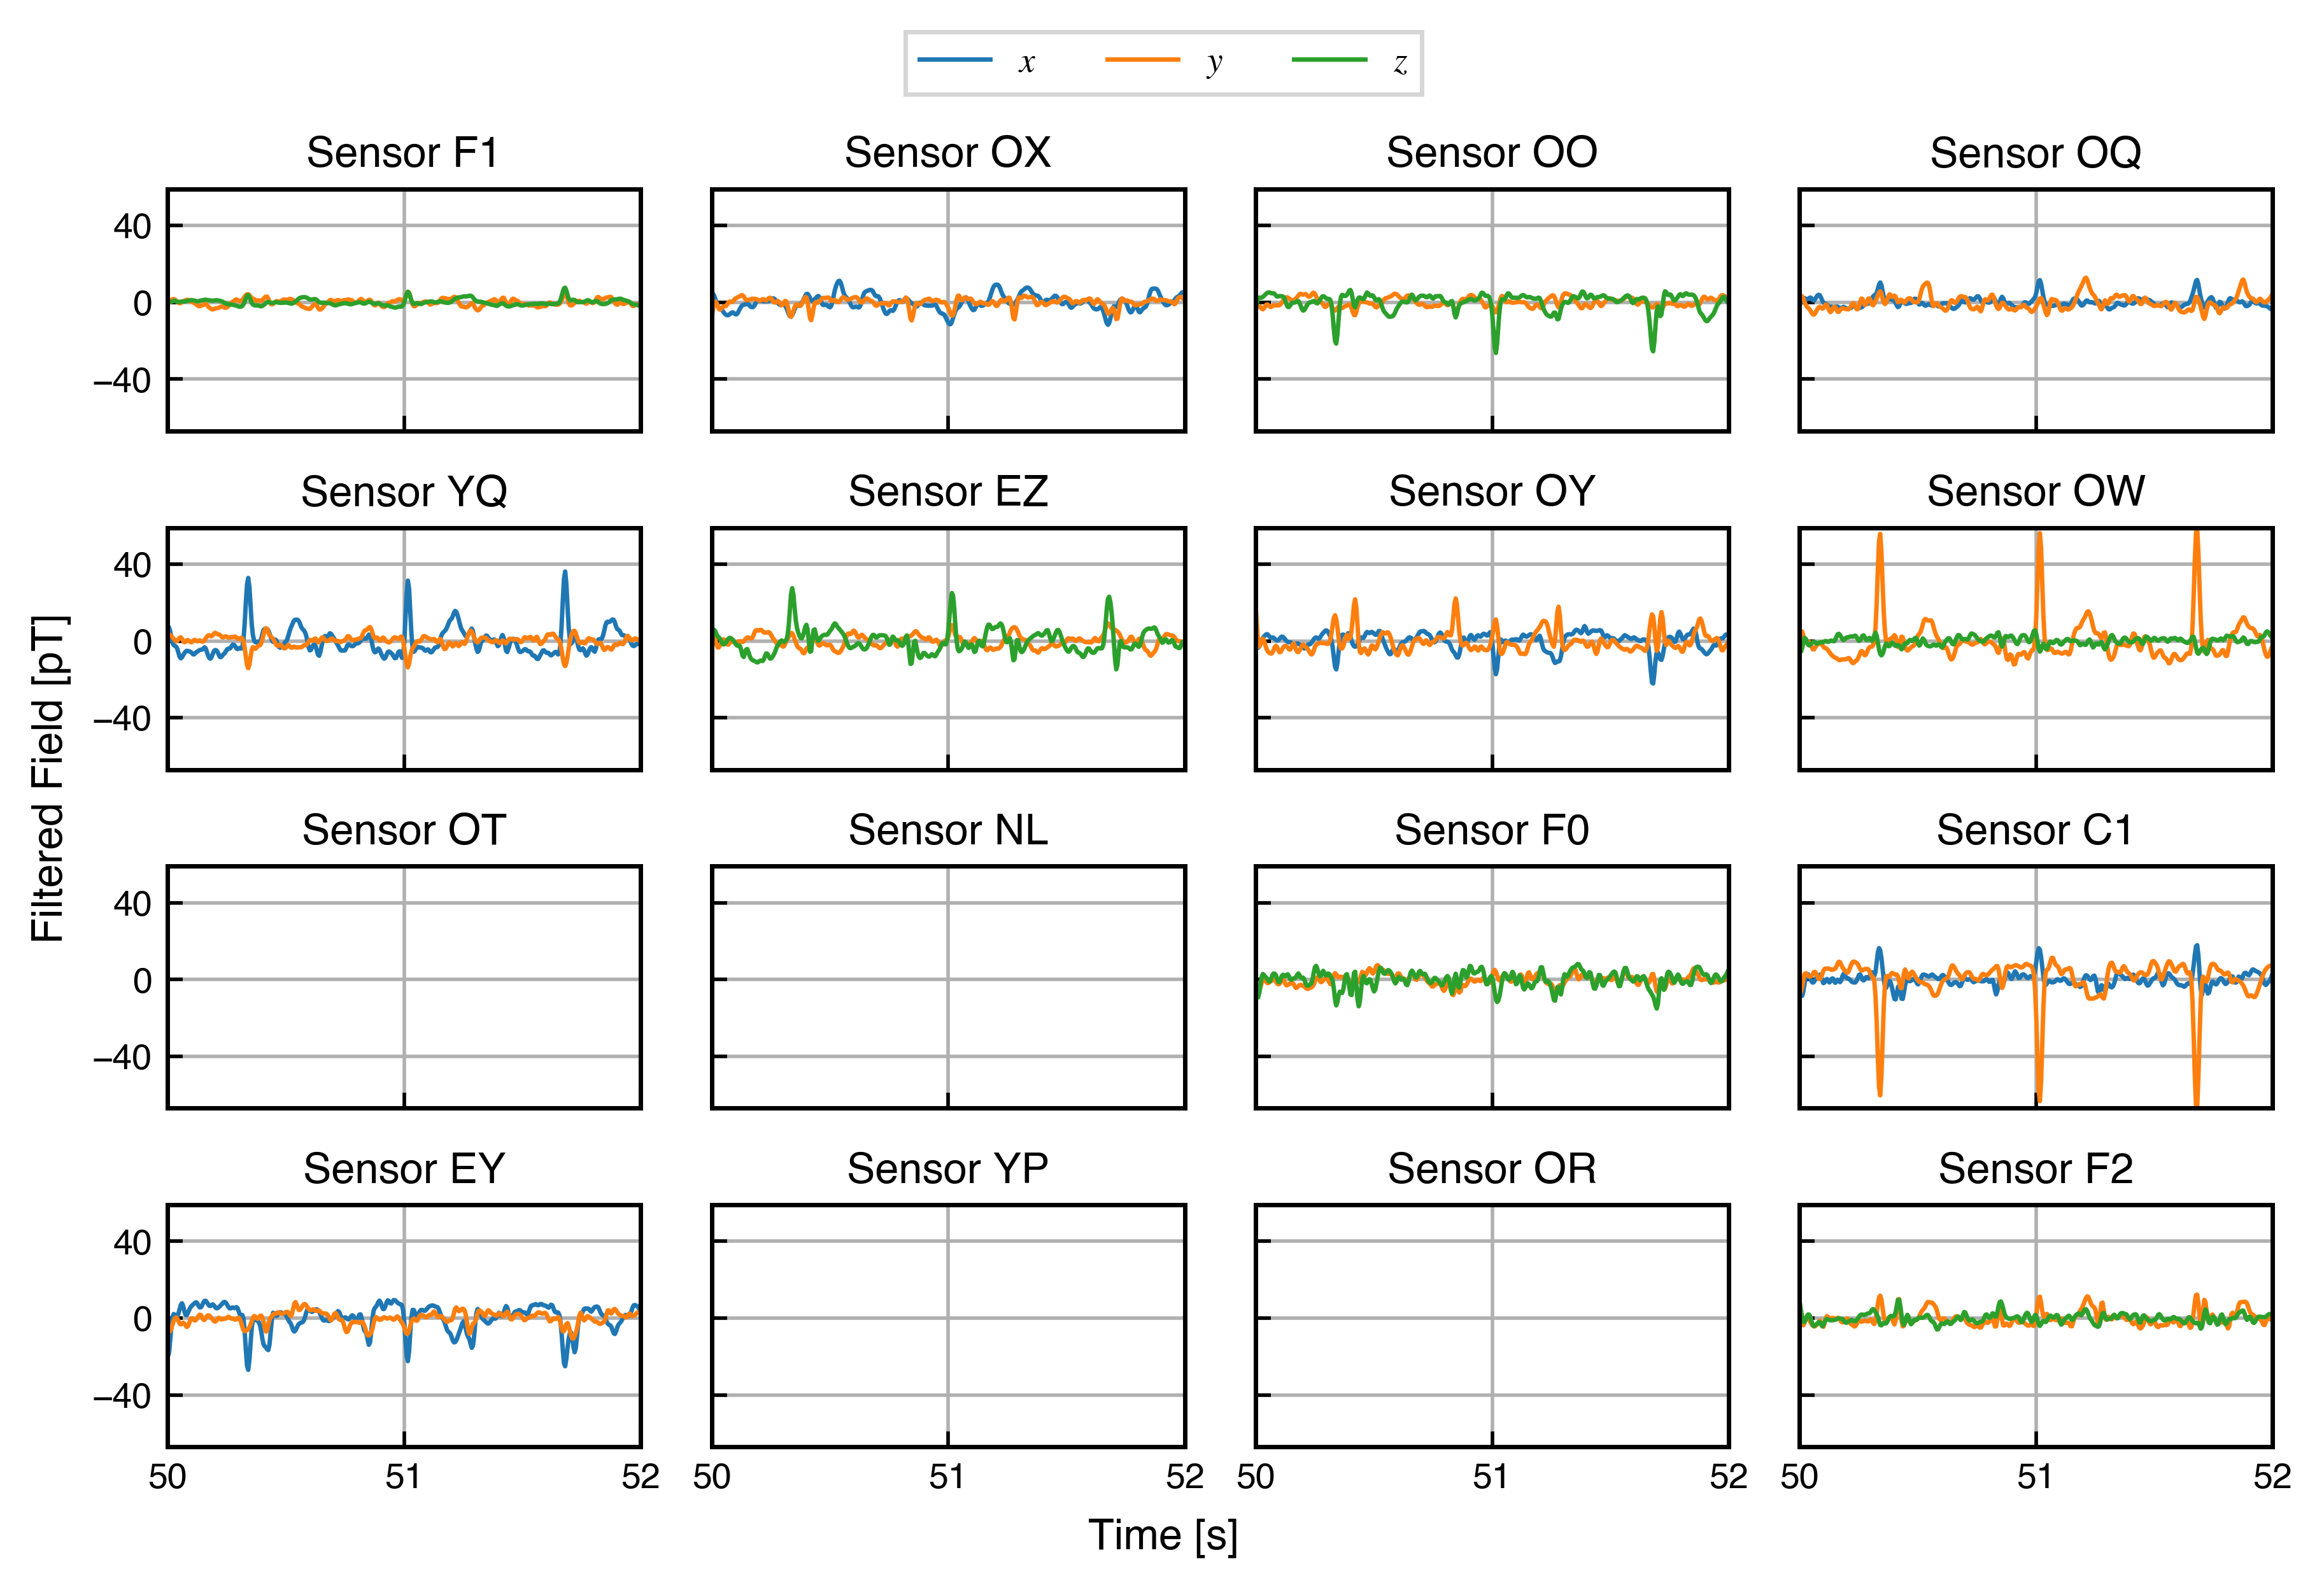

In [ ]:
DS_PATH = os.path.dirname(os.path.abspath('.')) + "/data"

field_maps, noise_maps, axis_mask, W_n, fs, time, r_sensors, artifacts_mask, sensor_names = load_and_preprocess(
    ds_path=DS_PATH,
    patient="P097",
    series="S07",
    sig_group_names="R001",
    noise_group_names="R004",
    whitening="PCA",
    downsample_factor=5,  # 1000 → 200 Hz
)

print(f"Preprocessed signal: {field_maps.shape[0]/fs:.1f}s at {fs} Hz, {int(axis_mask.sum())} valid channels")

plot_sensor_signals(
    field_maps,
    time,
    ylabel="Filtered Field [pT]",
    xlim=[50, 52],
    sharey=True,
    sensor_names=sensor_names,
)

## Independent Component Subtraction (ICS)

In [4]:
%matplotlib widget
plt.close('all')

labeler = ICAComponentLabeler.from_filtered_signal(                             
      signal=field_maps,
      fs=fs,                                                                                     
      time=time,
      axis_mask=axis_mask,                                                                             
      n_components=10,                                                                  
      seed=42,
      xlim=(10, 15),                   
      canvas_size=("300px", "30px"),     
      fig_size=(8, 2),
      base_path="./_ica_annotation"
)                             
labeler.show()      

NameError: name 'ICAComponentLabeler' is not defined

In [3]:
plt.close('all')
%matplotlib inline

annotation = labeler.get_results()
sources = annotation['sources']                            
ica_mixing_ = annotation['mixing_matrix']                                      
fetals = np.where(np.array(annotation['component_labels']) == "Fetal")[0]
maternals = np.where(np.array(annotation['component_labels']) == "Maternal")[0]
sources = annotation["sources"]
ica = annotation['ica']

NameError: name 'labeler' is not defined

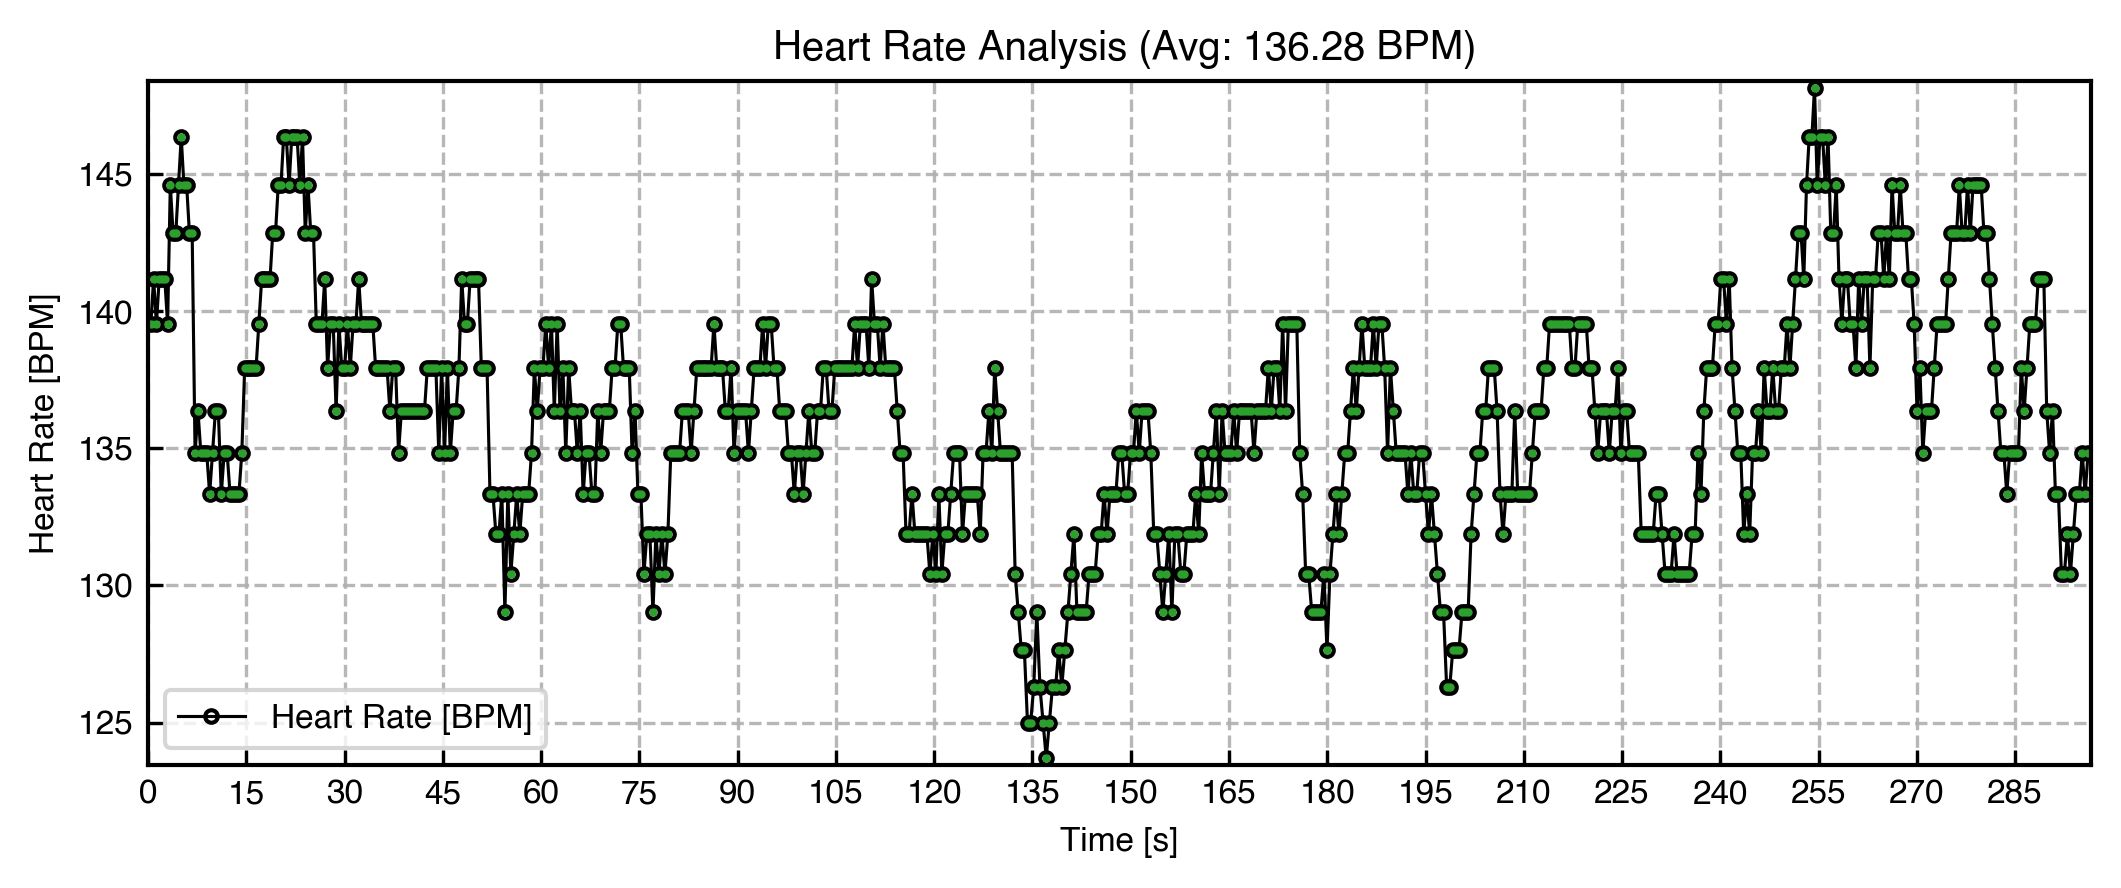

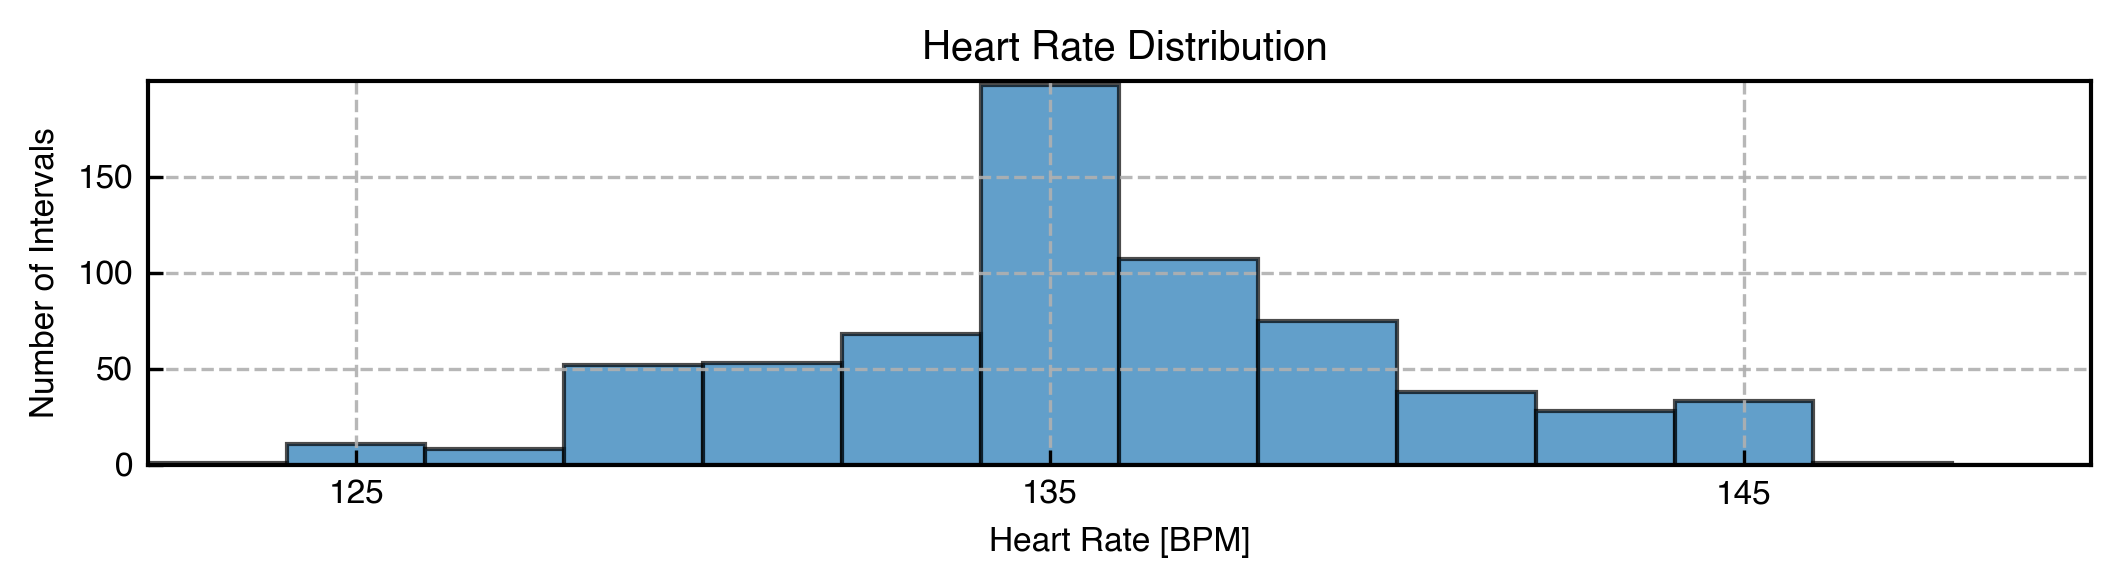

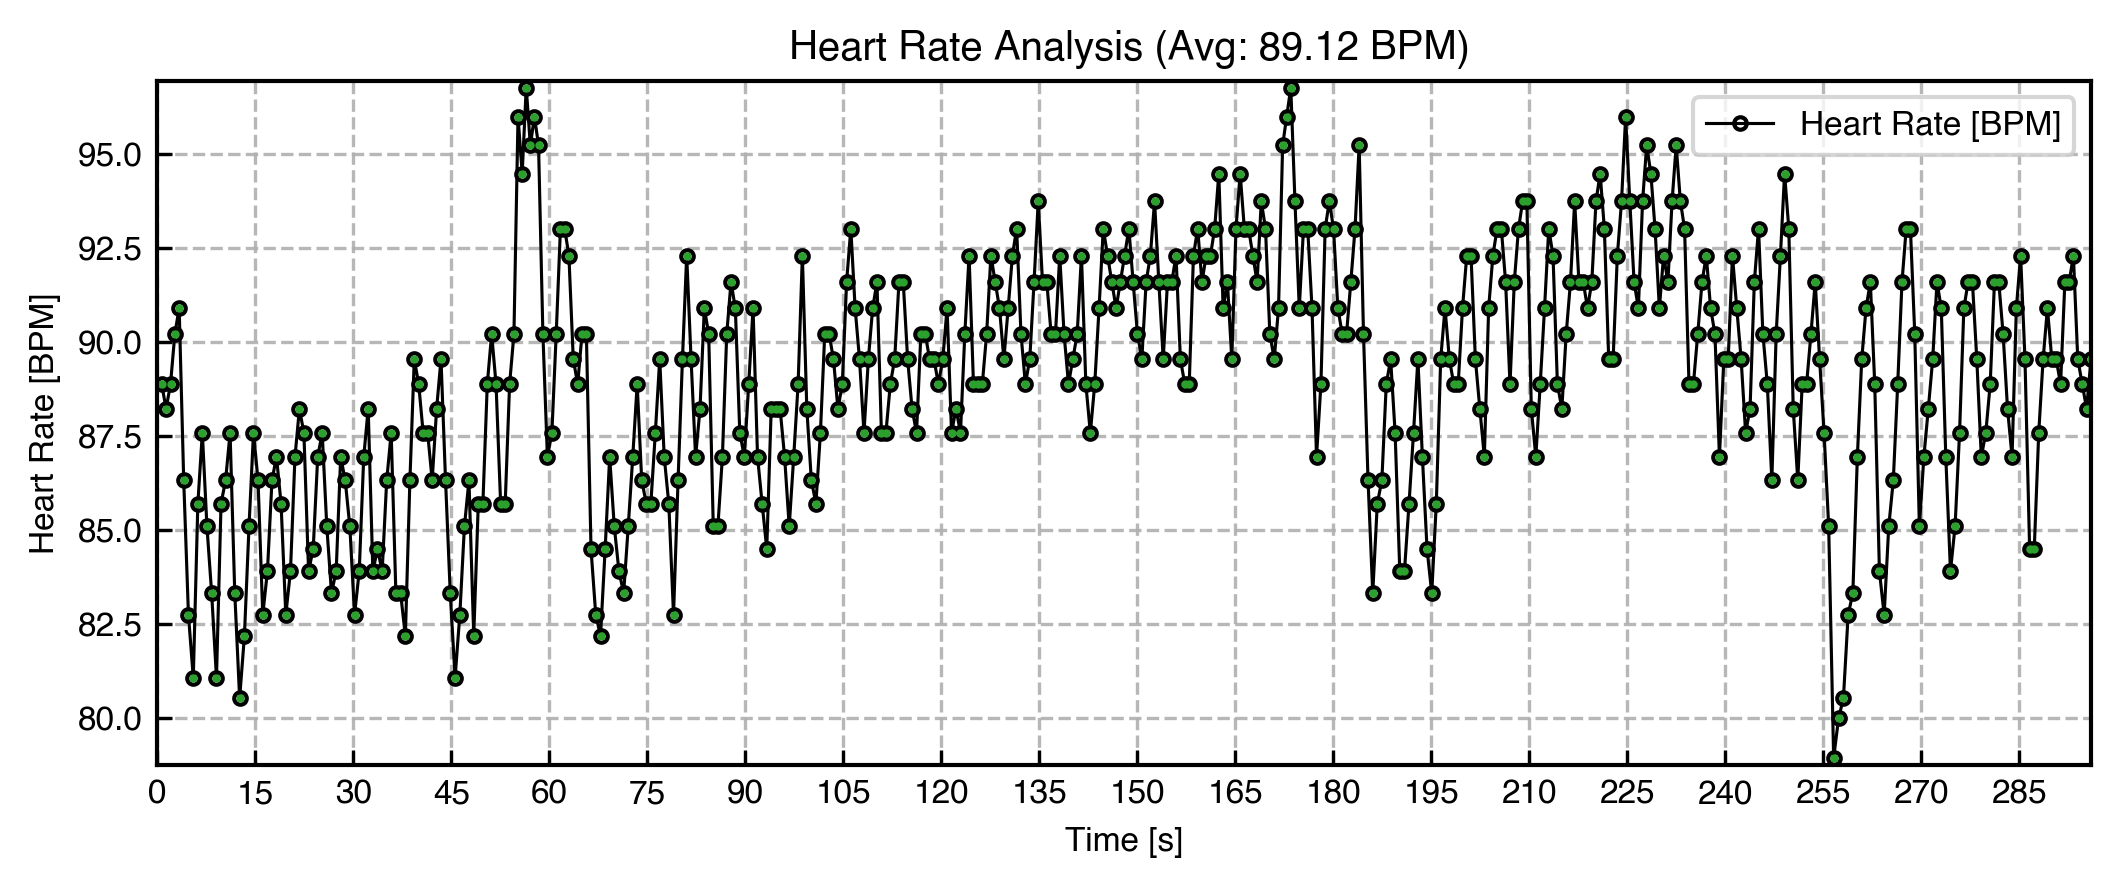

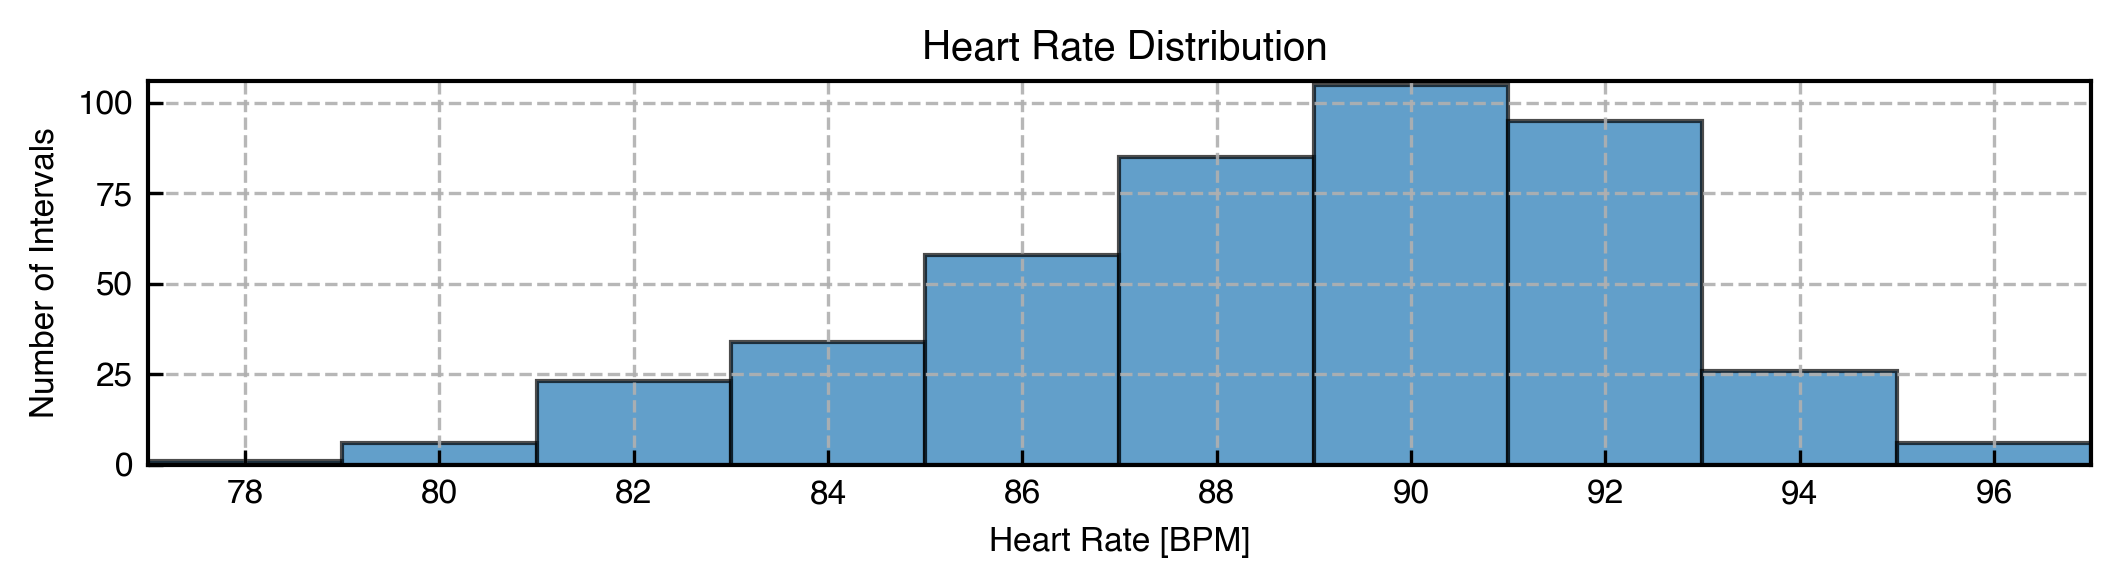

In [6]:
# Compute Heartrate of fetal cardiac signal
HR_f, peaks_f = compute_hr(sources, fs, fetals)
HR_m, peaks_m = compute_hr(sources, fs, maternals)

# Wiener Spatial Filter LMMSE

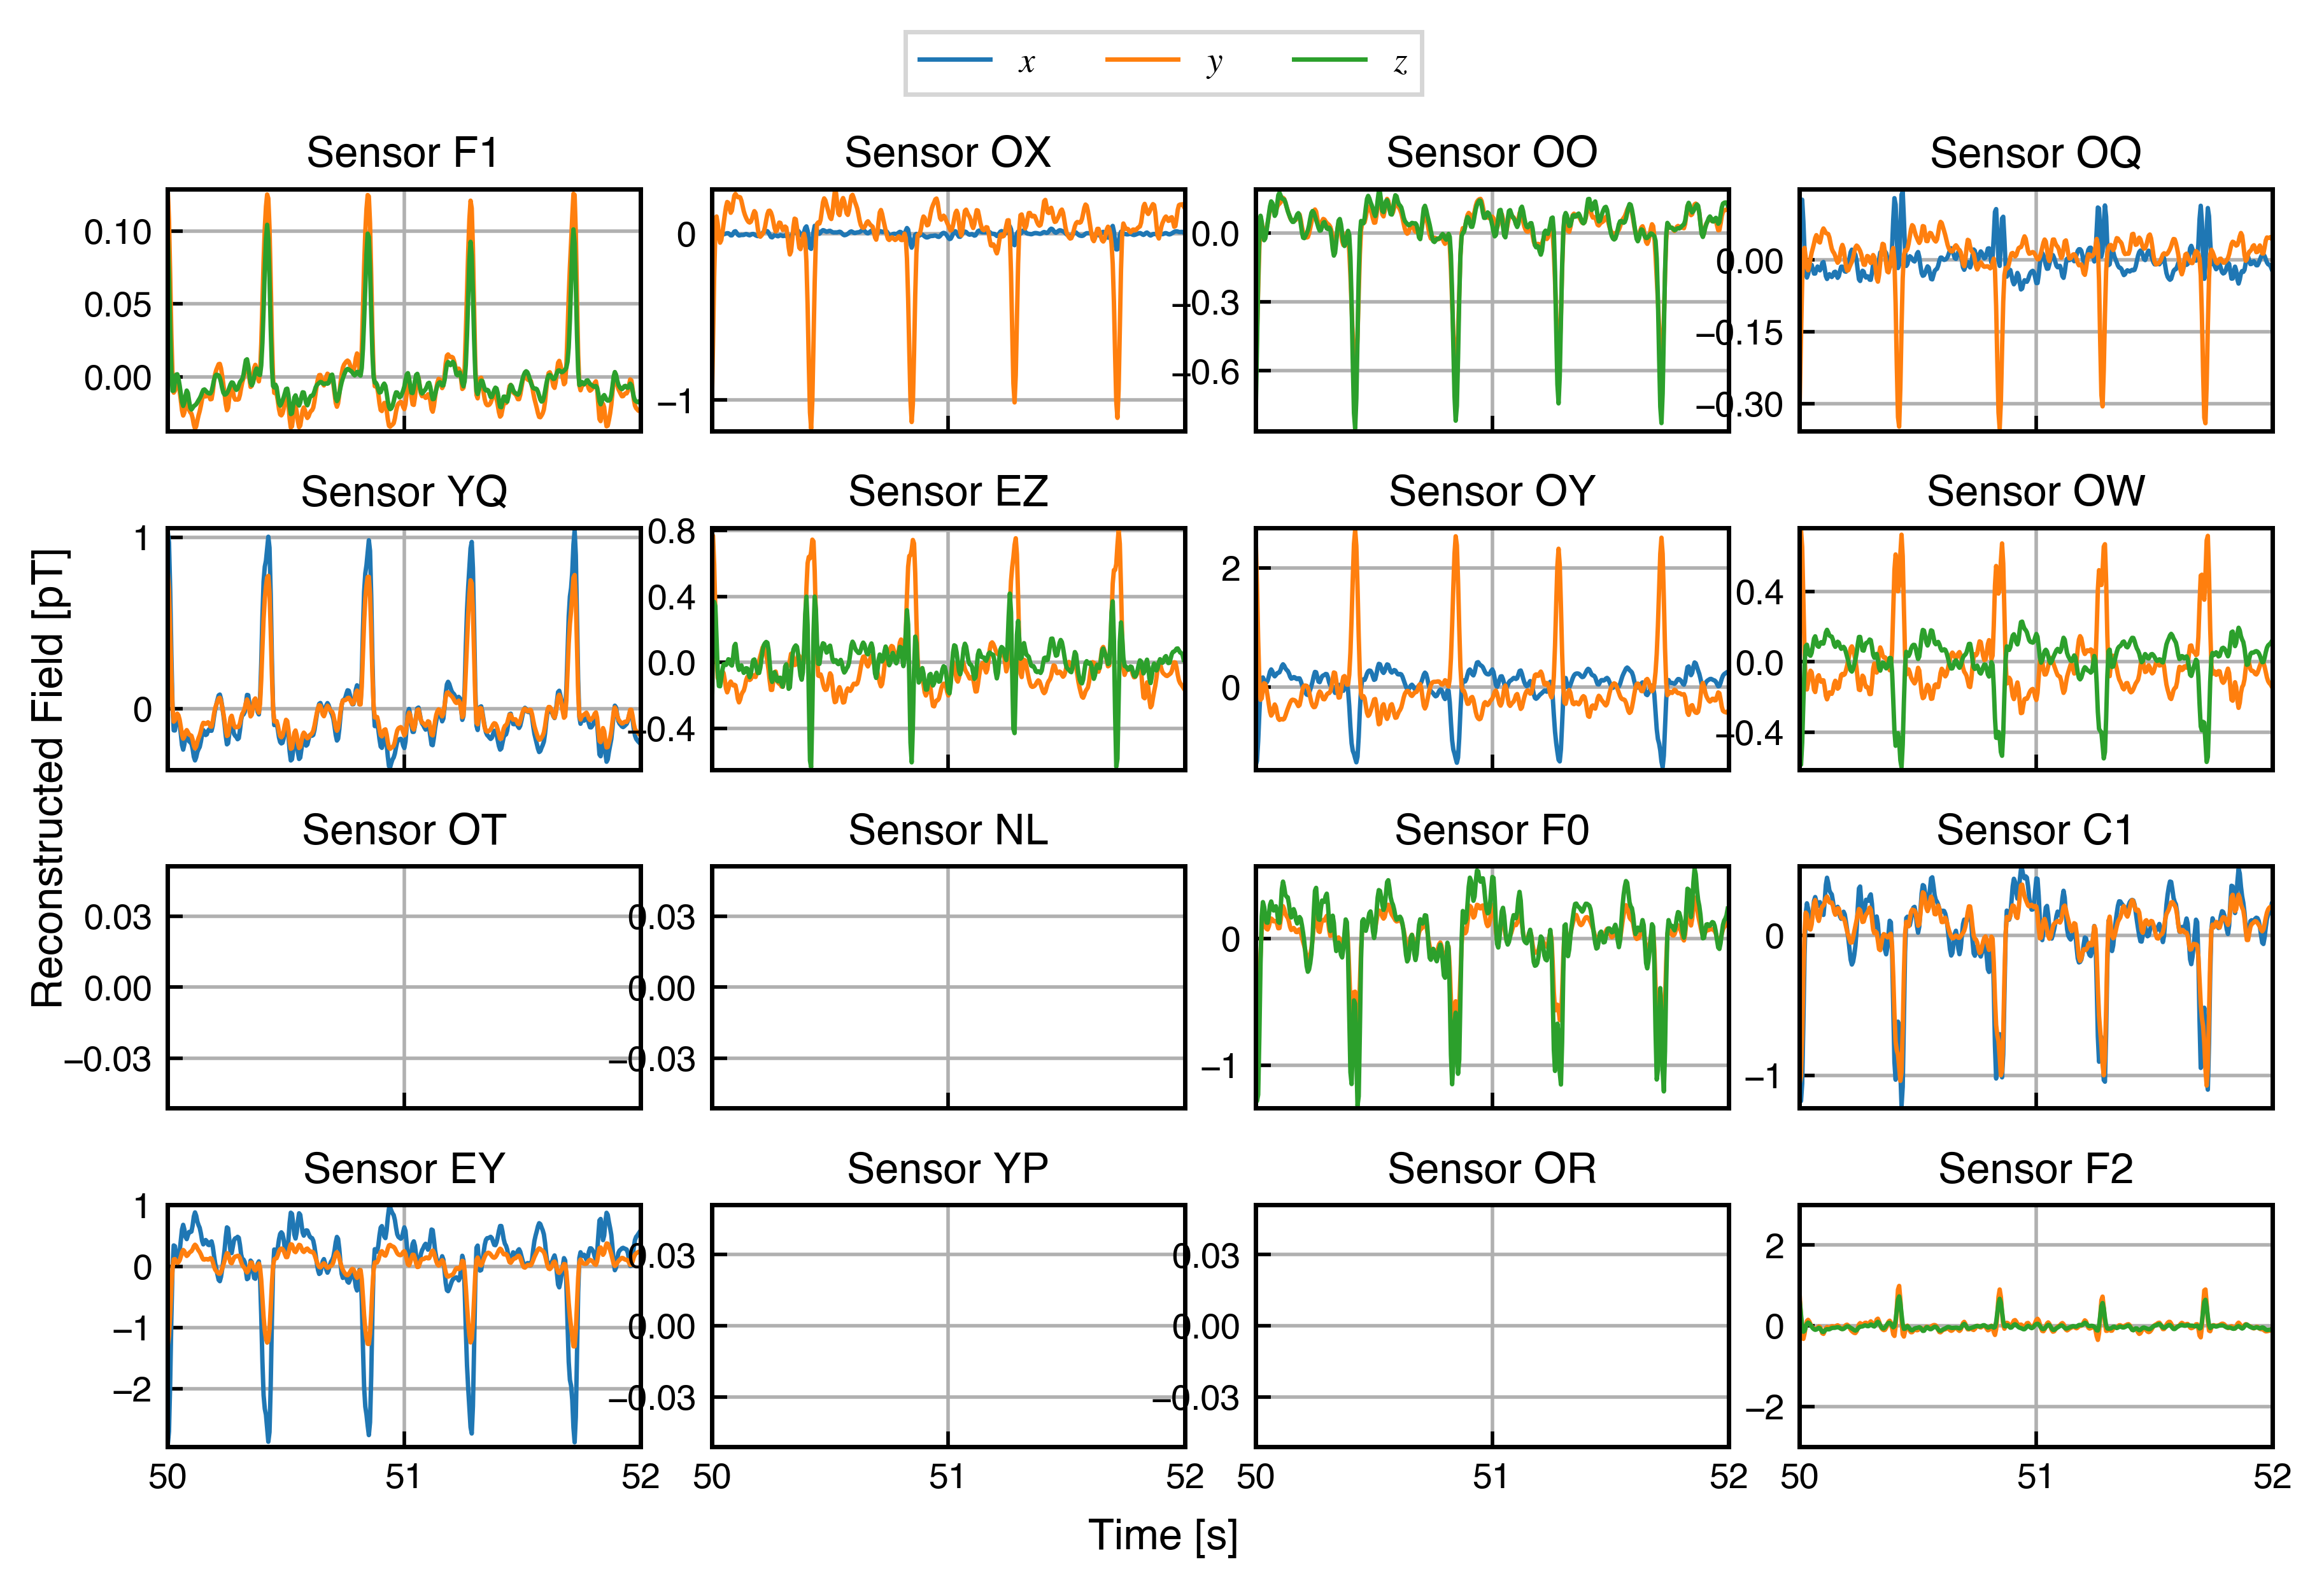

In [13]:
# Construct spatial filter from fetal peak series and apply it to the signal
sf = SpatialFilter(
    method="lmmse",
    fs=fs,
    enhance={"sources": sources, "comps": fetals},
)
field_lmmse = sf.apply(field_maps[:, axis_mask])

# optional post-filtering
field_lmmse = filternk(field_lmmse, fs, method="biosppy")

# Plot the reconstructed signal
plot_sensor_signals(
    fmcg.reduced2full(field_lmmse, axis_mask),
    time,
    ylabel="Reconstructed Field [pT]",
    xlim=[50, 52],
    sharey=False,
    sensor_names=sensor_names,
)

# Post Processing - Heartbeat Averaging

/jonas/fmcg/fmcg/analysis/heartbeat_averaging.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


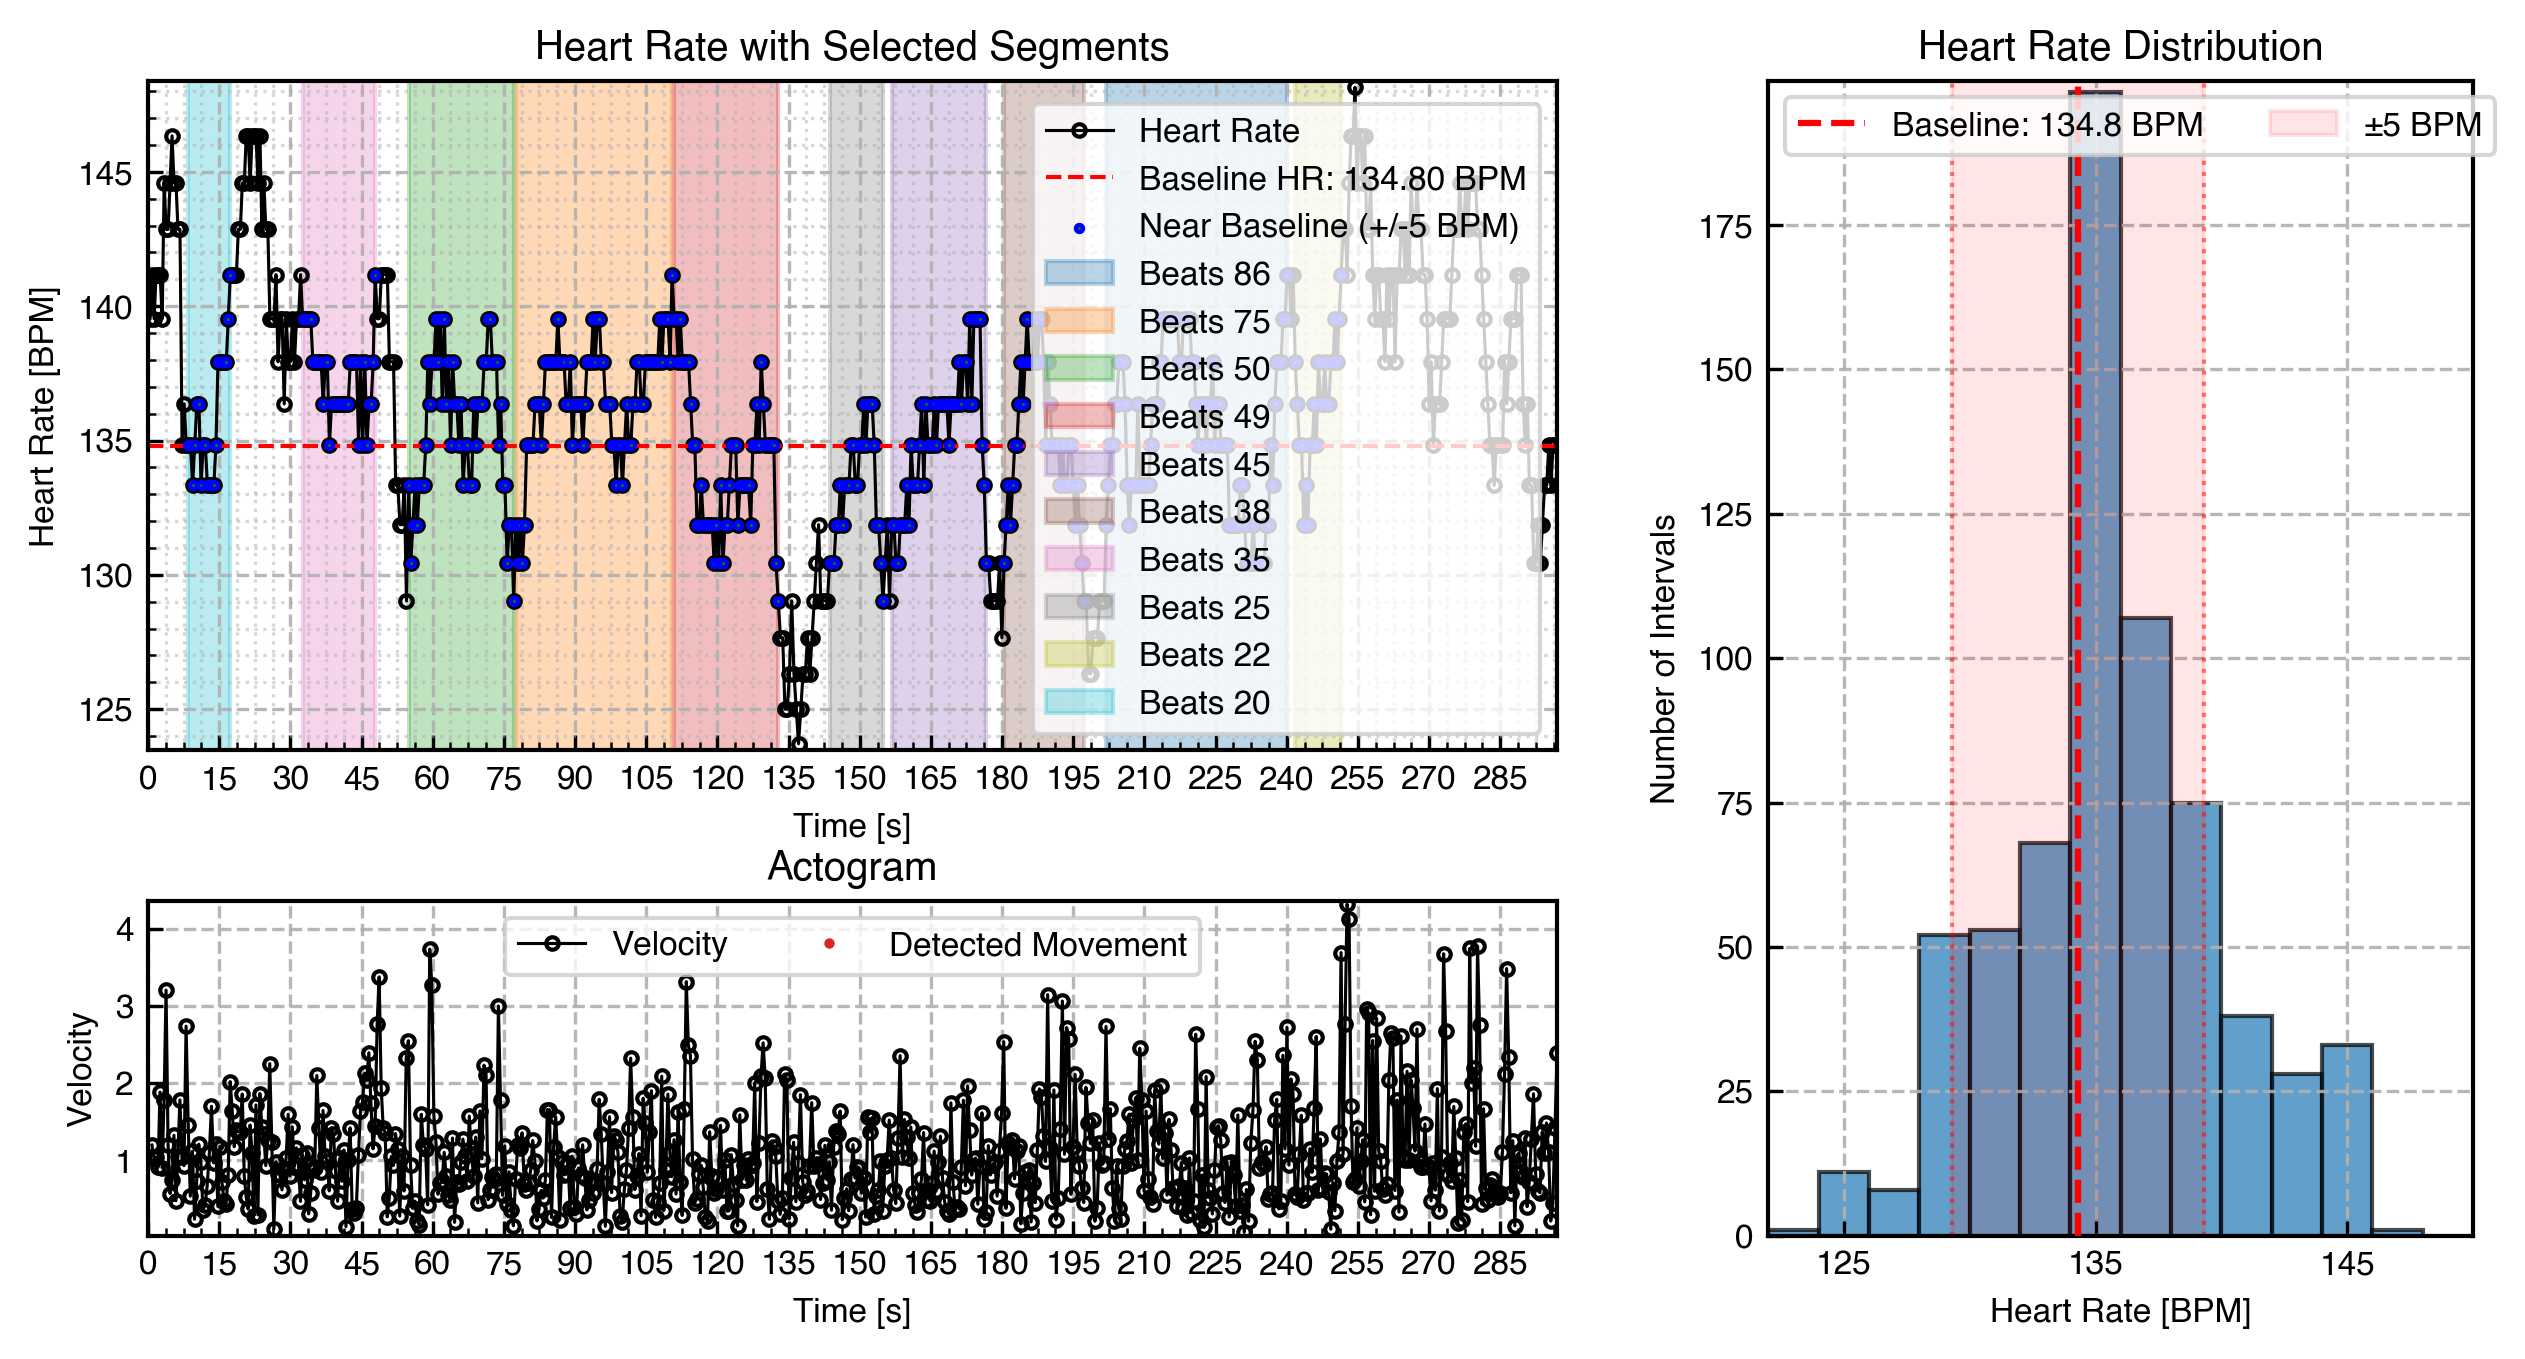

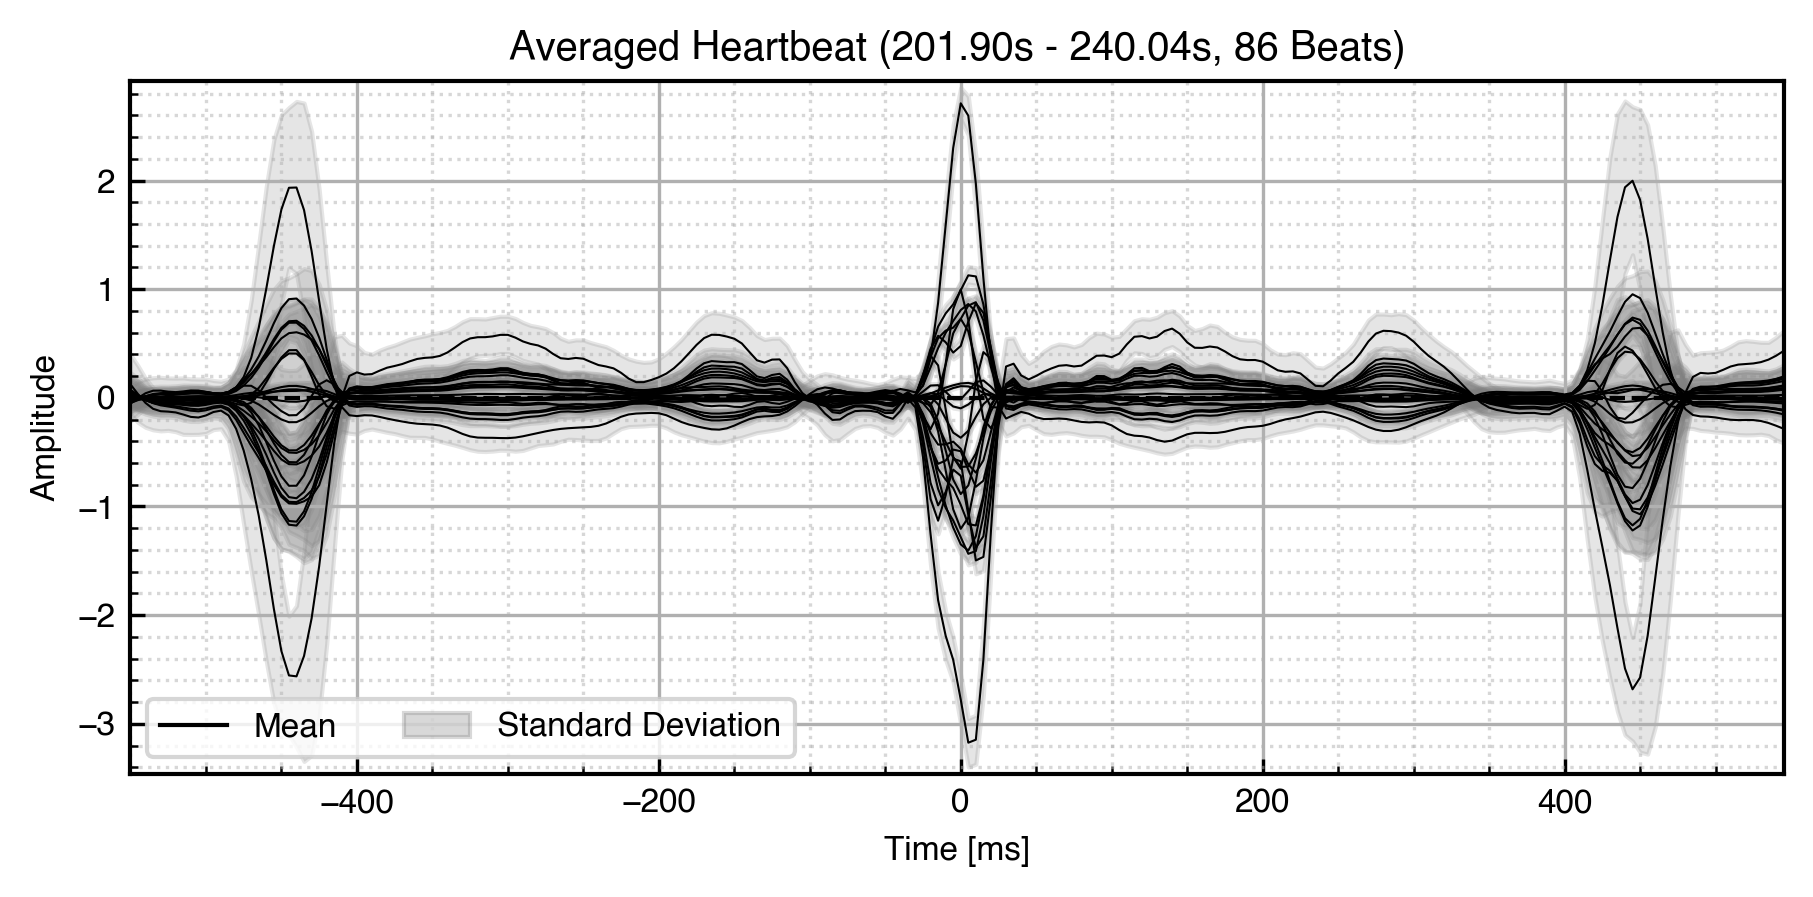

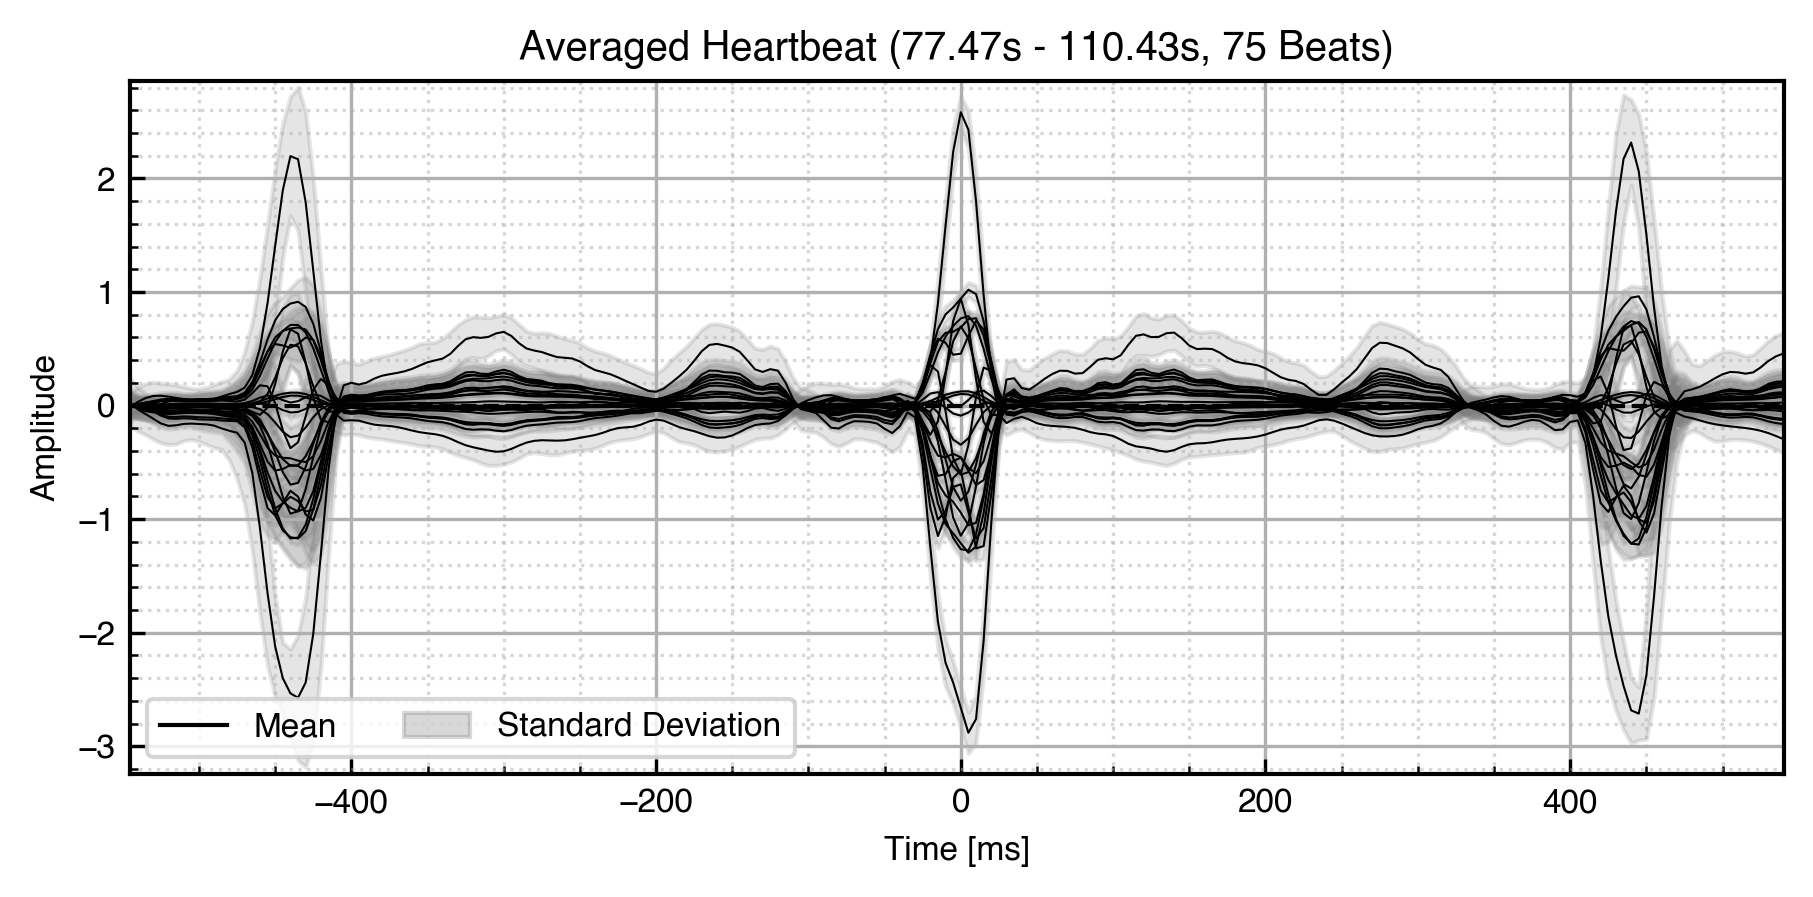

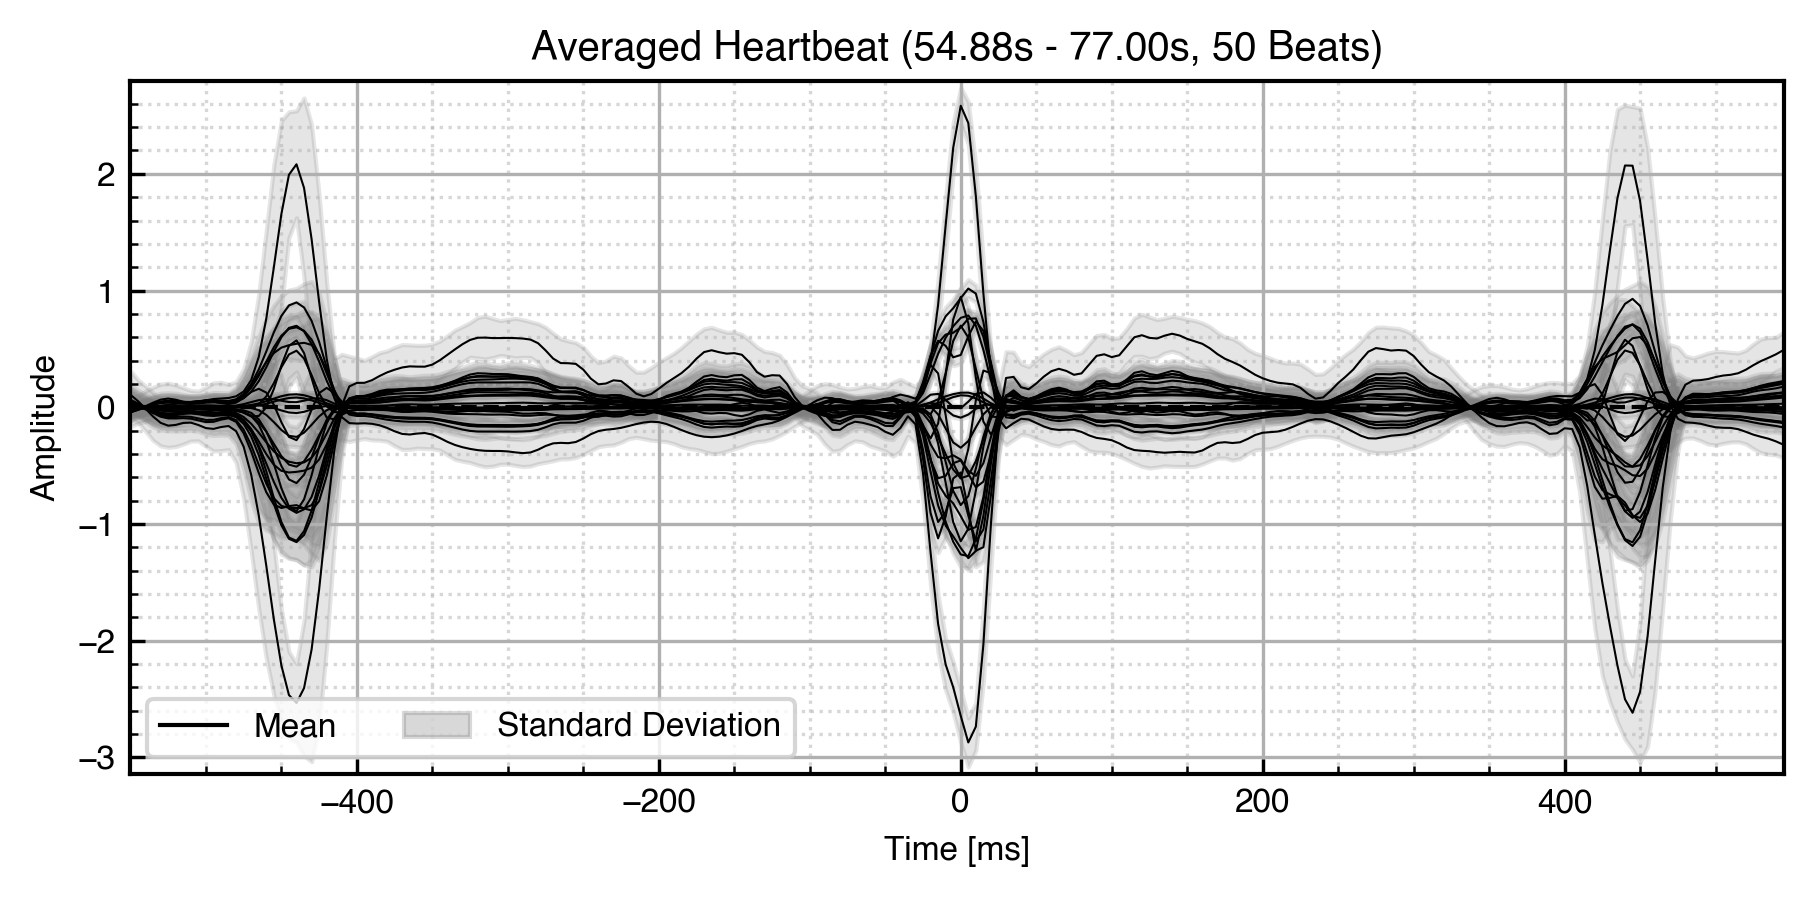

In [16]:
_ = find_segments_and_average_heartbeats(peaks_f, field_lmmse, fs)